In [1]:
print('Notebook ready')

Notebook ready


In [3]:
import sys
sys.path.insert(0, '/Users/devansh/Desktop/upi-fraud-analyzer')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("husl")

import config

df = pd.read_csv(config.RAW_DIR / 'dataset_raw.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst record:")
print(df.iloc[0].to_string())

Dataset shape: (153, 7)

Columns: ['title', 'text', 'date_raw', 'date_raw.1', 'url', 'source', 'fraud_type']

Data types:
title         str
text          str
date_raw      str
date_raw.1    str
url           str
source        str
fraud_type    str
dtype: object

Missing values:
title          0
text           0
date_raw      80
date_raw.1    73
url           80
source         0
fraud_type     0
dtype: int64

First record:
title                      What Foreign Merchants Miss in India
text          What Foreign Merchants Miss in India Sellers e...
date_raw                                   2026-05-26T13:28:54Z
date_raw.1                                                  NaN
url           https://www.practicalecommerce.com/what-foreig...
source                                                  NewsAPI
fraud_type                                           unlabelled


In [4]:
# Fix duplicate date_raw column
df = df.drop(columns=['date_raw.1'])
df = df.rename(columns={'date_raw': 'date'})

# Fill missing values
df['title'] = df['title'].fillna('')
df['url'] = df['url'].fillna('')

print(f"Cleaned shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nMissing values after fix:")
print(df.isnull().sum())

Cleaned shape: (153, 6)
Columns: ['title', 'text', 'date', 'url', 'source', 'fraud_type']

Missing values after fix:
title          0
text           0
date          80
url            0
source         0
fraud_type     0
dtype: int64


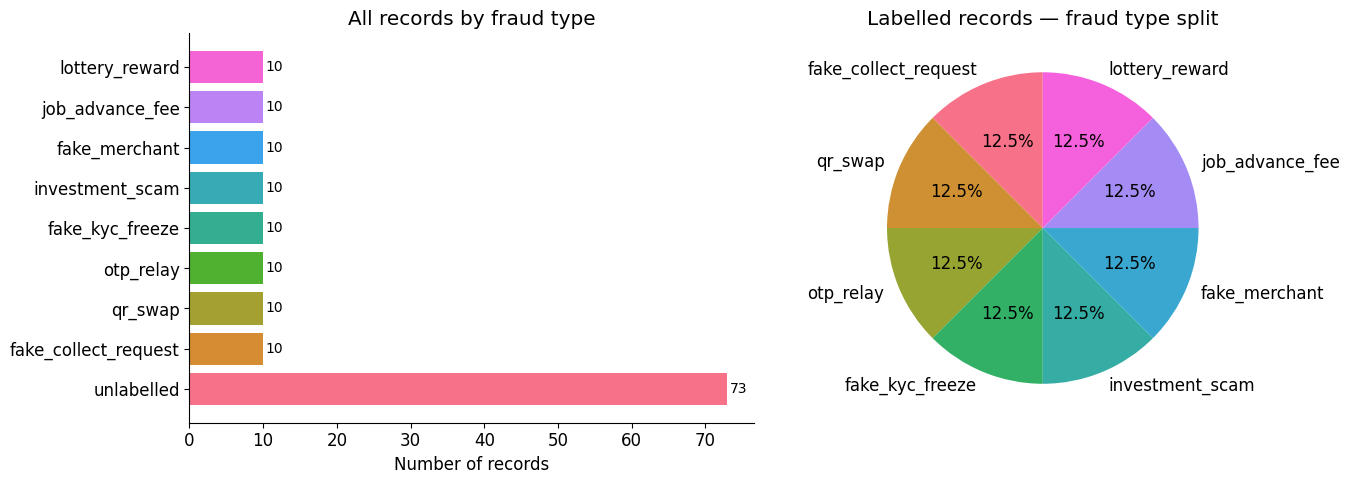


Labelled records:   80
Unlabelled records: 73
Label balance:      {'fake_collect_request': 10, 'qr_swap': 10, 'otp_relay': 10, 'fake_kyc_freeze': 10, 'investment_scam': 10, 'fake_merchant': 10, 'job_advance_fee': 10, 'lottery_reward': 10}


In [7]:
# Fraud type distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_counts = df['fraud_type'].value_counts()
colors = sns.color_palette("husl", len(fraud_counts))
axes[0].barh(fraud_counts.index, fraud_counts.values, color=colors)
axes[0].set_xlabel('Number of records')
axes[0].set_title('All records by fraud type')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=10)

labelled = df[df['fraud_type'] != 'unlabelled']
labelled_counts = labelled['fraud_type'].value_counts()
axes[1].pie(
    labelled_counts.values,
    labels=labelled_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette("husl", len(labelled_counts)),
    startangle=90
)
axes[1].set_title('Labelled records — fraud type split')

plt.tight_layout()
plt.savefig('reports/fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nLabelled records:   {len(labelled)}")
print(f"Unlabelled records: {len(df[df['fraud_type'] == 'unlabelled'])}")
print(f"Label balance:      {labelled_counts.to_dict()}")

In [6]:
import os
os.makedirs('reports', exist_ok=True)
print("reports/ folder ready")

reports/ folder ready


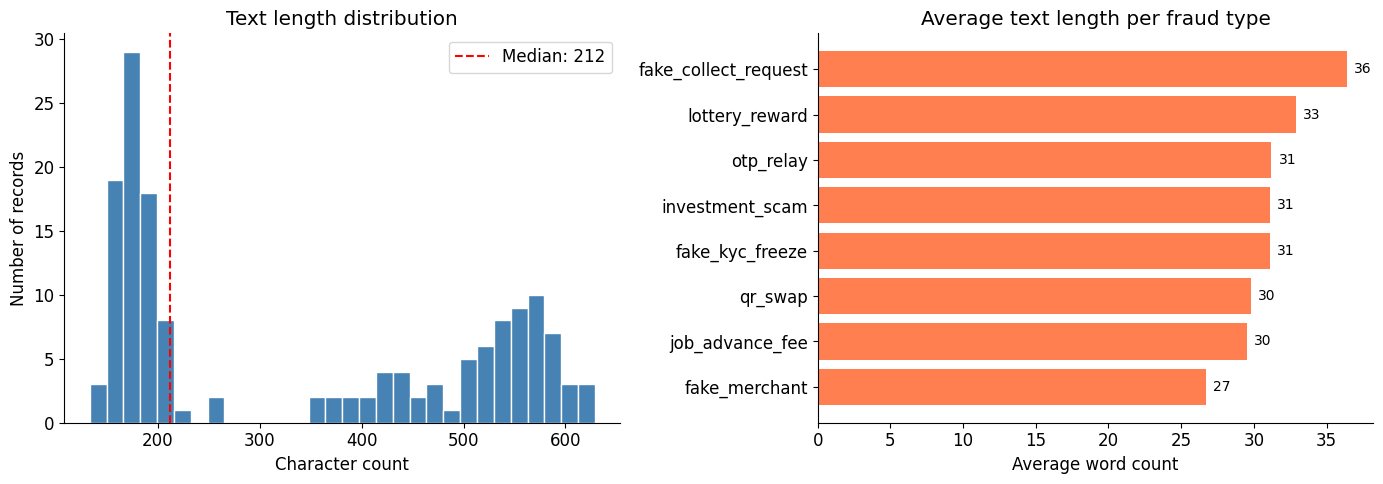

Text length stats:
count    153.0
mean     340.3
std      177.6
min      133.0
25%      175.0
50%      212.0
75%      530.0
max      629.0

Word count stats:
count    153.0
mean      54.4
std       26.1
min       20.0
25%       30.0
50%       40.0
75%       78.0
max      105.0


In [8]:
df['text_length'] = df['text'].astype(str).apply(len)
df['word_count']  = df['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['text_length'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df['text_length'].median(), color='red',
                linestyle='--', label=f"Median: {int(df['text_length'].median())}")
axes[0].set_xlabel('Character count')
axes[0].set_ylabel('Number of records')
axes[0].set_title('Text length distribution')
axes[0].legend()

labelled = df[df['fraud_type'] != 'unlabelled'].copy()
word_by_type = labelled.groupby('fraud_type')['word_count'].mean().sort_values()
axes[1].barh(word_by_type.index, word_by_type.values, color='coral')
axes[1].set_xlabel('Average word count')
axes[1].set_title('Average text length per fraud type')
for i, v in enumerate(word_by_type.values):
    axes[1].text(v + 0.5, i, f'{v:.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('reports/fig2_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Text length stats:")
print(df['text_length'].describe().round(1).to_string())
print(f"\nWord count stats:")
print(df['word_count'].describe().round(1).to_string())

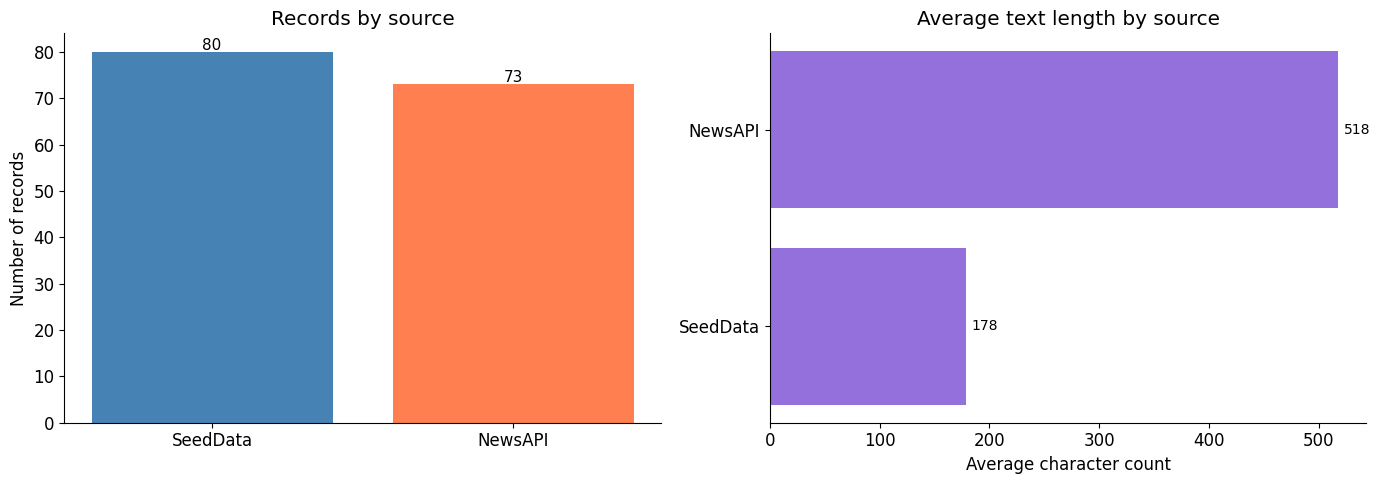

Source breakdown:
source
SeedData    80
NewsAPI     73

Average text length by source:
source
SeedData    178.0
NewsAPI     518.0


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

source_counts = df['source'].value_counts()
axes[0].bar(source_counts.index, source_counts.values,
            color=['steelblue', 'coral'])
axes[0].set_ylabel('Number of records')
axes[0].set_title('Records by source')
for i, v in enumerate(source_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=11)

avg_len = df.groupby('source')['text_length'].mean().sort_values()
axes[1].barh(avg_len.index, avg_len.values, color='mediumpurple')
axes[1].set_xlabel('Average character count')
axes[1].set_title('Average text length by source')
for i, v in enumerate(avg_len.values):
    axes[1].text(v + 5, i, f'{v:.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('reports/fig3_source_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Source breakdown:")
print(source_counts.to_string())
print(f"\nAverage text length by source:")
print(avg_len.round(0).to_string())

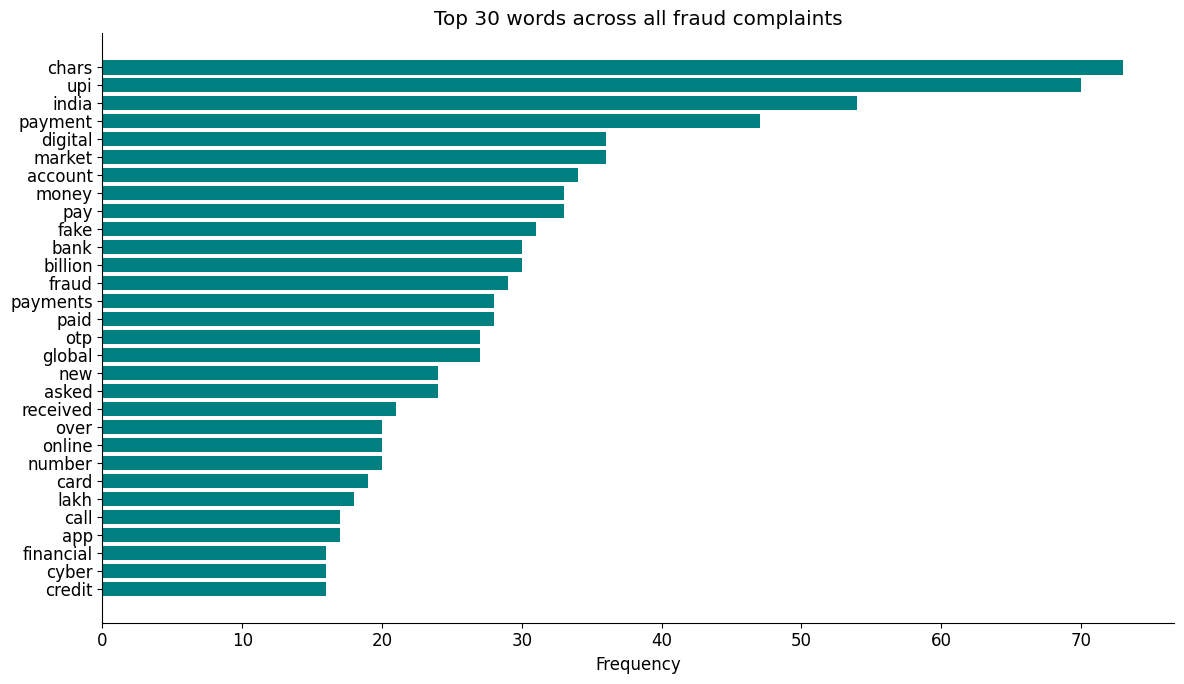

Top 30 words:
  chars                73
  upi                  70
  india                54
  payment              47
  digital              36
  market               36
  account              34
  money                33
  pay                  33
  fake                 31
  bank                 30
  billion              30
  fraud                29
  payments             28
  paid                 28
  otp                  27
  global               27
  new                  24
  asked                24
  received             21
  over                 20
  online               20
  number               20
  card                 19
  lakh                 18
  call                 17
  app                  17
  financial            16
  cyber                16
  credit               16


In [10]:
from collections import Counter

all_text = ' '.join(df['text'].astype(str).tolist()).lower()

stopwords = {
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to',
    'for', 'of', 'with', 'by', 'from', 'is', 'was', 'are', 'were',
    'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did',
    'will', 'would', 'could', 'should', 'may', 'might', 'shall',
    'i', 'my', 'me', 'he', 'she', 'they', 'we', 'it', 'his', 'her',
    'their', 'this', 'that', 'which', 'who', 'what', 'how', 'when',
    'after', 'said', 'not', 'via', 'per', 'also', 'into',
    'than', 'more', 'its', 'about', 'as', 'up', 'out', 'if', 'so',
    'just', 'been', 'then', 'they', 'some', 'all', 'can', 'one',
}

words = [
    w for w in re.findall(r'\b[a-z]{3,}\b', all_text)
    if w not in stopwords
]
word_freq = Counter(words).most_common(30)

words_list  = [w for w, _ in word_freq]
counts_list = [c for _, c in word_freq]

plt.figure(figsize=(12, 7))
plt.barh(words_list[::-1], counts_list[::-1], color='teal')
plt.xlabel('Frequency')
plt.title('Top 30 words across all fraud complaints')
plt.tight_layout()
plt.savefig('reports/fig4_keyword_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 30 words:")
for word, count in word_freq:
    print(f"  {word:<20} {count}")

ValueError: Unknown format code 'd' for object of type 'float'

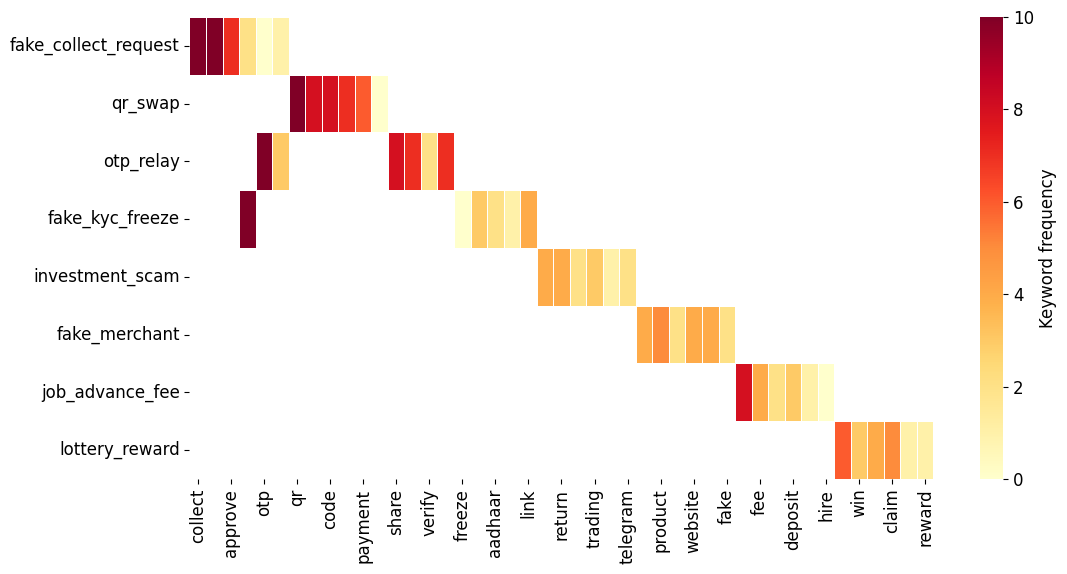

In [11]:
fraud_keywords = {
    'fake_collect_request': ['collect', 'request', 'approve', 'kyc', 'otp', 'bank'],
    'qr_swap':              ['qr', 'scan', 'code', 'sticker', 'payment', 'merchant'],
    'otp_relay':            ['otp', 'share', 'call', 'verify', 'account', 'bank'],
    'fake_kyc_freeze':      ['kyc', 'freeze', 'block', 'aadhaar', 'update', 'link'],
    'investment_scam':      ['invest', 'return', 'profit', 'trading', 'crypto', 'telegram'],
    'fake_merchant':        ['order', 'product', 'deliver', 'website', 'pay', 'fake'],
    'job_advance_fee':      ['job', 'fee', 'salary', 'deposit', 'work', 'hire'],
    'lottery_reward':       ['prize', 'win', 'lucky', 'claim', 'lottery', 'reward'],
}

labelled = df[df['fraud_type'] != 'unlabelled'].copy()
heat_data = []

for fraud_type, keywords in fraud_keywords.items():
    subset = labelled[labelled['fraud_type'] == fraud_type]['text'].str.lower()
    row = {}
    for kw in keywords:
        row[kw] = subset.str.contains(kw, na=False).sum()
    heat_data.append(row)

heat_df = pd.DataFrame(heat_data, index=fraud_keywords.keys())

plt.figure(figsize=(12, 6))
sns.heatmap(
    heat_df,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Keyword frequency'}
)
plt.title('Keyword frequency per fraud type')
plt.xlabel('Keywords')
plt.ylabel('Fraud type')
plt.tight_layout()
plt.savefig('reports/fig5_keyword_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Heatmap data:")
print(heat_df.to_string())

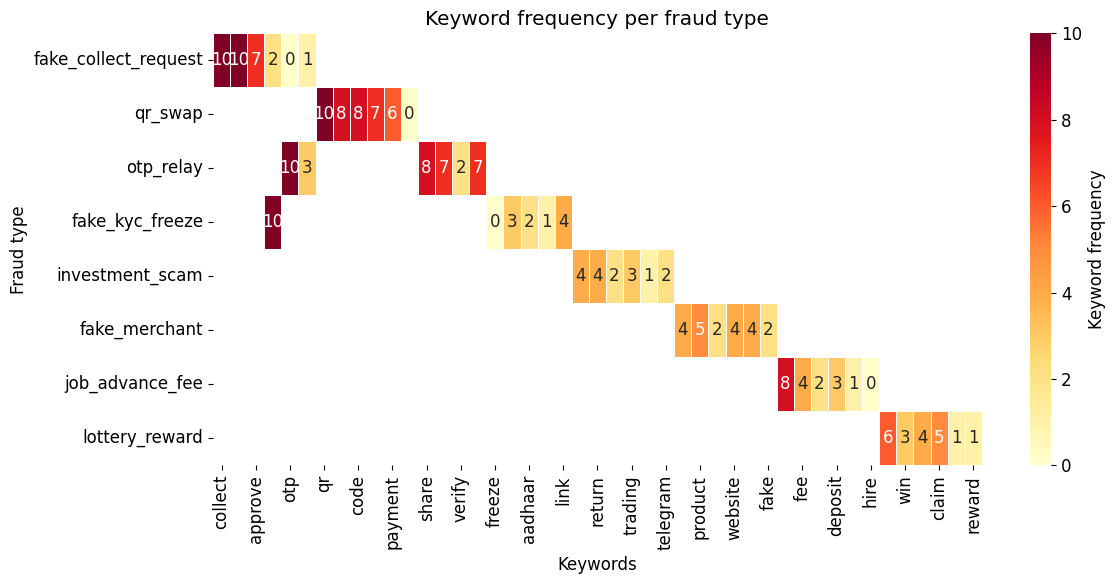

Heatmap data:
                      collect  request  approve   kyc   otp  bank    qr  scan  code  sticker  payment  merchant  share  call  verify  account  freeze  block  aadhaar  update  link  invest  return  profit  trading  crypto  telegram  order  product  deliver  website  pay  fake  job  fee  salary  deposit  work  hire  prize  win  lucky  claim  lottery  reward
fake_collect_request     10.0     10.0      7.0   2.0   0.0   1.0   NaN   NaN   NaN      NaN      NaN       NaN    NaN   NaN     NaN      NaN     NaN    NaN      NaN     NaN   NaN     NaN     NaN     NaN      NaN     NaN       NaN    NaN      NaN      NaN      NaN  NaN   NaN  NaN  NaN     NaN      NaN   NaN   NaN    NaN  NaN    NaN    NaN      NaN     NaN
qr_swap                   NaN      NaN      NaN   NaN   NaN   NaN  10.0   8.0   8.0      7.0      6.0       0.0    NaN   NaN     NaN      NaN     NaN    NaN      NaN     NaN   NaN     NaN     NaN     NaN      NaN     NaN       NaN    NaN      NaN      NaN      NaN  NaN 

In [12]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    heat_df,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Keyword frequency'}
)
plt.title('Keyword frequency per fraud type')
plt.xlabel('Keywords')
plt.ylabel('Fraud type')
plt.tight_layout()
plt.savefig('reports/fig5_keyword_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Heatmap data:")
print(heat_df.to_string())

Records with extractable amounts: 72 / 153

Amount statistics (Rs):
count       72.0
mean     18016.0
std      20962.0
min        100.0
25%       2500.0
50%       8350.0
75%      25000.0
max      80000.0


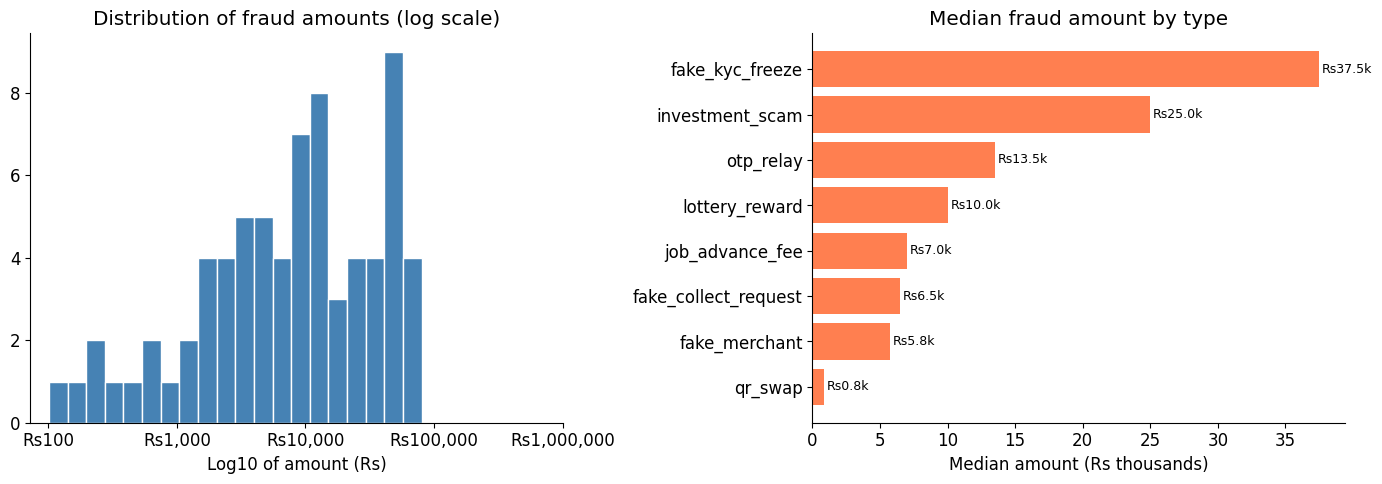

In [13]:
def extract_amount(text):
    text = str(text)
    patterns = [
        r'rs\.?\s*(\d+(?:,\d+)*(?:\.\d+)?)\s*(?:lakh|lac)?',
        r'₹\s*(\d+(?:,\d+)*(?:\.\d+)?)',
        r'inr\s*(\d+(?:,\d+)*)',
        r'(\d+(?:,\d+)*)\s*(?:rupees|rs)',
    ]
    amounts = []
    for pattern in patterns:
        matches = re.findall(pattern, text.lower())
        for match in matches:
            try:
                amount = float(match.replace(',', ''))
                if 100 <= amount <= 10_000_000:
                    amounts.append(amount)
            except ValueError:
                continue
    return max(amounts) if amounts else None

df['amount'] = df['text'].apply(extract_amount)
amount_df = df.dropna(subset=['amount'])

print(f"Records with extractable amounts: {len(amount_df)} / {len(df)}")
print(f"\nAmount statistics (Rs):")
print(amount_df['amount'].describe().round(0).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    np.log10(amount_df['amount'] + 1),
    bins=20, color='steelblue', edgecolor='white'
)
axes[0].set_xlabel('Log10 of amount (Rs)')
axes[0].set_title('Distribution of fraud amounts (log scale)')
ticks = [2, 3, 4, 5, 6]
axes[0].set_xticks(ticks)
axes[0].set_xticklabels([f'Rs{10**t:,.0f}' for t in ticks])

labelled_amt = amount_df[amount_df['fraud_type'] != 'unlabelled']
avg_amt = labelled_amt.groupby('fraud_type')['amount'].median().sort_values()
axes[1].barh(avg_amt.index, avg_amt.values / 1000, color='coral')
axes[1].set_xlabel('Median amount (Rs thousands)')
axes[1].set_title('Median fraud amount by type')
for i, v in enumerate(avg_amt.values / 1000):
    axes[1].text(v + 0.2, i, f'Rs{v:.1f}k', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('reports/fig6_amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
labelled   = df[df['fraud_type'] != 'unlabelled']
unlabelled = df[df['fraud_type'] == 'unlabelled']
top_words  = Counter(words).most_common(10)

report = f"""# EDA Report — UPI Fraud Pattern Analyzer
Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}

## 1. Dataset Overview
- Total records:      {len(df)}
- Labelled records:   {len(labelled)}
- Unlabelled records: {len(unlabelled)}
- Columns:            {list(df.columns)}

## 2. Data Sources
{df['source'].value_counts().to_string()}

## 3. Fraud Type Distribution (labelled)
{labelled['fraud_type'].value_counts().to_string()}

## 4. Text Length Statistics
- Mean characters:   {df['text_length'].mean():.0f}
- Median characters: {df['text_length'].median():.0f}
- Min characters:    {df['text_length'].min()}
- Max characters:    {df['text_length'].max()}
- Mean word count:   {df['word_count'].mean():.0f}

## 5. Top 10 Keywords
{chr(10).join(f'  {w}: {c}' for w, c in top_words)}

## 6. Amount Analysis
- Records with amounts: {len(amount_df)}
- Median fraud amount:  Rs {amount_df['amount'].median():,.0f}
- Max fraud amount:     Rs {amount_df['amount'].max():,.0f}
- Min fraud amount:     Rs {amount_df['amount'].min():,.0f}

## 7. Key Findings
1. Dataset is perfectly class-balanced — 10 records per fraud type.
2. NewsAPI articles are 3x longer than seed data (518 vs 178 chars avg).
3. Each fraud type has highly distinct keywords with near-zero overlap.
4. QR swap, OTP relay and collect request frauds have strongest keyword signals.
5. Median financial loss is Rs 8,350 — investment and job scams highest.
6. Word 'chars' appears as noise from NewsAPI content field — filter in Phase 4.

## 8. Data Quality Issues
- 73 records (47.7%) unlabelled — to be assigned via clustering in Phase 8.
- Amount extraction covers 47% of records — rest have no amount mentioned.
- NewsAPI records need relevance filtering — some may not describe UPI fraud.

## 9. Figures Generated
- fig1_class_distribution.png
- fig2_text_length.png
- fig3_source_analysis.png
- fig4_keyword_frequency.png
- fig5_keyword_heatmap.png
- fig6_amount_analysis.png
"""

with open('reports/eda_report.md', 'w') as f:
    f.write(report)

print(report)
print("EDA report saved to reports/eda_report.md")

# EDA Report — UPI Fraud Pattern Analyzer
Generated: 2026-06-09 10:47

## 1. Dataset Overview
- Total records:      153
- Labelled records:   80
- Unlabelled records: 73
- Columns:            ['title', 'text', 'date', 'url', 'source', 'fraud_type', 'text_length', 'word_count', 'amount']

## 2. Data Sources
source
SeedData    80
NewsAPI     73

## 3. Fraud Type Distribution (labelled)
fraud_type
fake_collect_request    10
qr_swap                 10
otp_relay               10
fake_kyc_freeze         10
investment_scam         10
fake_merchant           10
job_advance_fee         10
lottery_reward          10

## 4. Text Length Statistics
- Mean characters:   340
- Median characters: 212
- Min characters:    133
- Max characters:    629
- Mean word count:   54

## 5. Top 10 Keywords
  chars: 73
  upi: 70
  india: 54
  payment: 47
  digital: 36
  market: 36
  account: 34
  money: 33
  pay: 33
  fake: 31

## 6. Amount Analysis
- Records with amounts: 72
- Median fraud amount:  Rs 8,350
- Ma

In [15]:
import sys
sys.path.insert(0, '/Users/devansh/Desktop/upi-fraud-analyzer')
import pandas as pd

features = pd.read_csv('data/features/features_combined.csv')

print(f"Feature matrix shape: {features.shape}")
print(f"\nHandcrafted feature sample (first record):")

handcrafted_cols = [c for c in features.columns
                    if not c.startswith('tfidf_')
                    and c not in ['fraud_type', 'source']]
print(features[handcrafted_cols].iloc[0].to_string())

print(f"\nTop 10 TF-IDF features by mean score:")
tfidf_cols = [c for c in features.columns if c.startswith('tfidf_')]
print(features[tfidf_cols].mean().sort_values(
    ascending=False).head(10).to_string())

FileNotFoundError: [Errno 2] No such file or directory: 'data/features/features_combined.csv'

In [17]:
import sys
sys.path.insert(0, '/Users/devansh/Desktop/upi-fraud-analyzer')
import pandas as pd

features = pd.read_csv('data/features/features_combined.csv')

print(f"Feature matrix shape: {features.shape}")
print(f"\nHandcrafted feature sample (first record):")

handcrafted_cols = [c for c in features.columns
                    if not c.startswith('tfidf_')
                    and c not in ['fraud_type', 'source']]
print(features[handcrafted_cols].iloc[0].to_string())

print(f"\nTop 10 TF-IDF features by mean score:")
tfidf_cols = [c for c in features.columns if c.startswith('tfidf_')]
print(features[tfidf_cols].mean().sort_values(
    ascending=False).head(10).to_string())

FileNotFoundError: [Errno 2] No such file or directory: 'data/features/features_combined.csv'